#  Principal Component Analysis (PCA) — Step-by-Step Guide


This notebook demonstrates **Principal Component Analysis (PCA)** using the **Iris dataset**.  
We will follow all steps — from data preparation, standardization, covariance matrix, eigen decomposition, 
to projection and visualization.


"""
###  Explanation — Step 1: Data Loading
- We use the **Iris dataset**, containing 150 samples and 4 features:
  - Sepal length, Sepal width, Petal length, Petal width.
- The target labels (Setosa, Versicolor, Virginica) are stored separately.
- PCA will only use the **feature matrix X**, not the labels, since it is an **unsupervised** method.
"""

In [33]:

# Step 1️ — Import libraries and load dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load Iris dataset
iris = datasets.load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species_id")
species = np.array(iris.target_names)

print(" Data loaded successfully — Shape:", X.shape)
X.head()


 Data loaded successfully — Shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [34]:
# Target
species

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

# Standardrdization
"""
###  Explanation — Step 2: Standardization
- Standardization ensures that each feature contributes equally to PCA.
- PCA is affected by scale; therefore, we must transform all features to have mean 0 and standard deviation 1.
- Example: Petal length (in cm) could otherwise dominate smaller-scaled features.
"""

In [35]:

# Step 2️ — Standardize the features
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print(" Data standardized (mean=0, std=1)")
pd.DataFrame(X_std, columns=iris.feature_names).head()


 Data standardized (mean=0, std=1)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444



"""
###  Explanation — Step 3: Covariance Matrix
- The **covariance matrix** captures how features vary together.
- If two features have a high positive covariance, they increase together.
- PCA uses this matrix to find the directions (principal components) with maximum variance.
"""

In [36]:

# Step 3️ — Compute covariance matrix
cov_matrix = np.cov(X_std, rowvar=False)
pd.DataFrame(cov_matrix, index=iris.feature_names, columns=iris.feature_names)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.006711,-0.118359,0.877604,0.823431
sepal width (cm),-0.118359,1.006711,-0.431316,-0.368583
petal length (cm),0.877604,-0.431316,1.006711,0.969328
petal width (cm),0.823431,-0.368583,0.969328,1.006711



"""
###  Explanation — Step 4: Eigen Decomposition
- Each **eigenvalue** represents the amount of variance captured by a corresponding **eigenvector** (principal component).
- Sorted eigenvalues show which components capture the most variance.
- **Cumulative explained variance** tells us how many components are needed to retain a chosen amount of total variance (e.g., 95%).
"""

In [37]:

# Step 4️ — Eigen decomposition
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

# Sort eigenvalues & eigenvectors
idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[idx]
eig_vecs = eig_vecs[:, idx]

explained_variance_ratio = eig_vals / eig_vals.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)

pd.DataFrame({
    "Eigenvalue": eig_vals,
    "Explained_Variance_Ratio": explained_variance_ratio,
    "Cumulative_Explained": cumulative_variance
}, index=[f"PC{i+1}" for i in range(len(eig_vals))])


,Eigenvalue,Explained_Variance_Ratio,Cumulative_Explained
PC1,2.938085,0.729624,0.729624
PC2,0.920165,0.228508,0.958132
PC3,0.147742,0.036689,0.994821
PC4,0.020854,0.005179,1.000000


"""
###  Explanation — Step 5: Choosing Number of Components
- We select the smallest **k** where the cumulative explained variance ≥ 0.95 (95%).
- In this dataset:
  - **PC1 = 72.96% variance**
  - **PC2 = 22.85% variance**
  - Together: **95.81% total variance** 
- Therefore, **k = 2 components** are enough to represent most of the information.
"""

In [38]:

# Step 5️ — Choose number of components (retain ≥95% variance)
k = np.argmax(cumulative_variance >= 0.95) + 1
print(f" Number of components for ≥95% variance: {k}")


 Number of components for ≥95% variance: 2


"""
###  Explanation — Step 6: Projection
- We multiply the standardized data by the top-k eigenvectors to project it onto the new lower-dimensional space.
- The resulting dataset `Z` now has only 2 columns: PC1 and PC2.
- These represent the new features capturing the majority of variance.
"""

In [39]:
# Step 6️ — Project data onto principal components
# #  Display feature loadings (coefficients) for PC1 and PC2
loadings = pd.DataFrame(
    eig_vecs[:, :k],
    index=iris.feature_names,
    columns=[f"PC{i+1}" for i in range(k)]
)

print("\n Feature Loadings for Selected Principal Components:")
display(loadings.round(4))



 Feature Loadings for Selected Principal Components:


,PC1,PC2
sepal length (cm),0.5211,-0.3774
sepal width (cm),-0.2693,-0.9233
petal length (cm),0.5804,-0.0245
petal width (cm),0.5649,-0.0669


In [40]:

# Step 6️ — Project data onto top-k components (manual PCA projection)
W = eig_vecs[:, :k]
Z = X_std @ W

pca_scores = pd.DataFrame(Z, columns=[f"PC{i+1}" for i in range(k)])
pca_scores["species"] = species[y.values]
pca_scores.head(10)


,PC1,PC2,species
0,-2.264703,-0.480027,setosa
1,-2.080961,0.674134,setosa
2,-2.364229,0.341908,setosa
3,-2.299384,0.597395,setosa
4,-2.389842,-0.646835,setosa
5,-2.075631,-1.489178,setosa
6,-2.444029,-0.047644,setosa
7,-2.232847,-0.223148,setosa
8,-2.334640,1.115328,setosa
9,-2.184328,0.469014,setosa


In [41]:
pca_scores.tail(10)

,PC1,PC2,species
140,2.014810,-0.613886,virginica
141,1.901784,-0.689575,virginica
142,1.157882,0.698870,virginica
143,2.040558,-0.867521,virginica
144,1.998147,-1.049169,virginica
145,1.870503,-0.386966,virginica
146,1.564580,0.896687,virginica
147,1.521170,-0.269069,virginica
148,1.372788,-1.011254,virginica
149,0.960656,0.024332,virginica


"""
###  Explanation — Step 7: Comparing Manual and sklearn PCA
- We verify our manual PCA with `sklearn.PCA` implementation.
- Both methods produce identical explained variance ratios — confirming correctness.
- Using sklearn is convenient for real-world applications, but understanding the math is essential.
"""

In [42]:

# Step 7️ — Compare with sklearn.PCA
pca = PCA(n_components=k)
Z_sklearn = pca.fit_transform(X_std)

compare = pd.DataFrame({
    "Manual": explained_variance_ratio[:k],
    "Sklearn": pca.explained_variance_ratio_
}, index=[f"PC{i+1}" for i in range(k)])
compare


,Manual,Sklearn
PC1,0.729624,0.729624
PC2,0.228508,0.228508


"""
###  Explanation — Step 8: Visualization
- **Scree Plot:** Shows how much variance each PC captures.
- **Cumulative Plot:** Helps decide how many PCs to retain (cutoff at 95%).
- **2D Scatter:** Visualizes data distribution across PC1 and PC2.

####  Interpretation:
- *Setosa* (blue) forms a distinct cluster → very different petal features.
- *Versicolor* (orange) and *Virginica* (green) overlap slightly → partially similar.
- **PC1 (~73%)**: dominated by petal size.
- **PC2 (~23%)**: influenced by sepal width.
- Together, PC1 + PC2 explain ~95.8% of the dataset variance.
"""

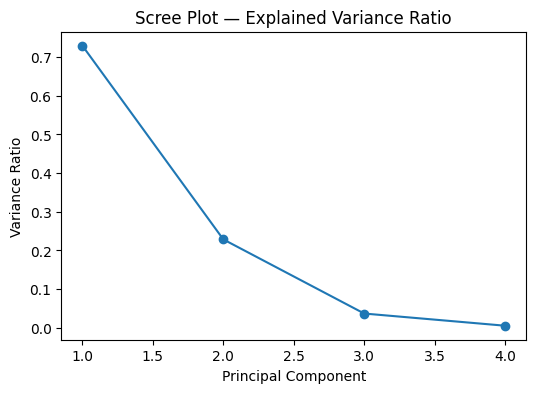

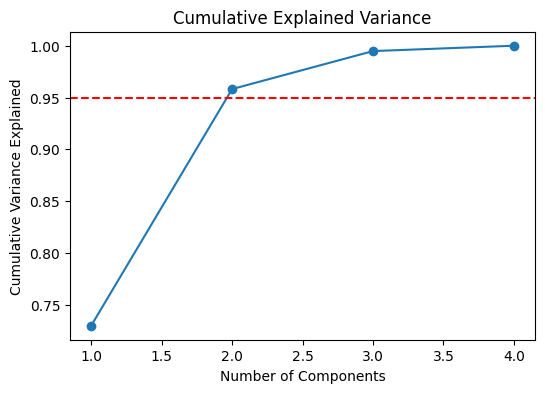

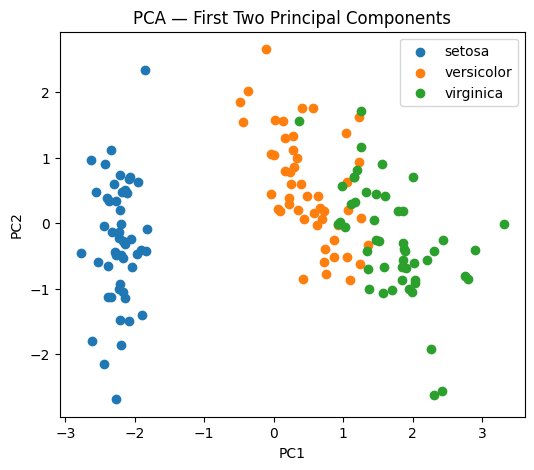

In [43]:

# Step 8️ — Visualization

# Scree Plot
plt.figure(figsize=(6,4))
plt.plot(range(1, len(eig_vals)+1), explained_variance_ratio, 'o-')
plt.title("Scree Plot — Explained Variance Ratio")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.show()

# Cumulative Variance
plt.figure(figsize=(6,4))
plt.plot(range(1, len(eig_vals)+1), cumulative_variance, 'o-')
plt.axhline(0.95, color='r', linestyle='--')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.show()

# 2D Scatter (first 2 PCs)
if k >= 2:
    plt.figure(figsize=(6,5))
    for label in np.unique(y):
        mask = (y == label)
        plt.scatter(Z[mask, 0], Z[mask, 1], label=species[label])
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("PCA — First Two Principal Components")
    plt.legend()
    plt.show()



###  Conclusion
- PCA reduced the Iris dataset from 4D → 2D while retaining ~95% of total variance.
- No target (label) was used — PCA is **unsupervised**.
- The label is used only for **visualization**.
